In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [3]:
import warnings
warnings.filterwarnings('ignore')

### Introduction and Data Loading
**Project Goal:** To explore the Taiwan credit card client dataset, understand the distributions and statistical summaries of the features, identify and handle outliers, and build a Gradient Boosting Regression model to predict the probability of default.

**Data Columns Overview:**
* **LIMIT_BAL:** Amount of the given credit (NT dollar). Includes individual and family/supplementary credit.
* **SEX:** Gender (1 = male; 2 = female).
* **EDUCATION:** Educational background (1 = graduate school; 2 = university; 3 = high school; 4 = others).
* **MARRIAGE:** Marital status (1 = married; 2 = single; 3 = others).
* **AGE:** Age of the client in years.
* **PAY_0 to PAY_6:** Repayment status from September 2005 to April 2005 (-1 = pay duly; 1-9 = payment delay in months).
* **BILL_AMT1 to BILL_AMT6:** Amount of bill statement (NT dollar) from September to April 2005.
* **PAY_AMT1 to PAY_AMT6:** Amount of previous payment (NT dollar) from September to April 2005.
* **default payment next month:** Target variable (1 = default, 0 = no default).

In [4]:
# Set plot style for beautiful graphs
sns.set_theme(style="whitegrid", palette="muted")

In [5]:
# Load the dataset
Raw_data = pd.read_csv('default_of_credit_card_clients.csv')

In [6]:
Raw_data.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


### **Initial Statistics and Observations**
Before diving into visual exploration, it is crucial to look at the raw statistics of the dataset. This helps us understand the scales of our variables and check our assumption that there are no missing values.

In [7]:
Raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [8]:
# Summary statistics for numerical and categorical columns
Raw_data.describe()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


### **Exploratory Data Analysis (EDA) - Categorical Variables**
Let's visualize the demographic categories and the target variable. 

**Expected Observations:**
* **Gender:** There are typically more female clients (2) than male clients (1) in this dataset.
* **Education:** Most clients hold a university degree or graduate school level of education.
* **Target Imbalance:** The `default payment next month` column is usually imbalanced, with a vast majority of clients not defaulting (0) compared to those who do (1).

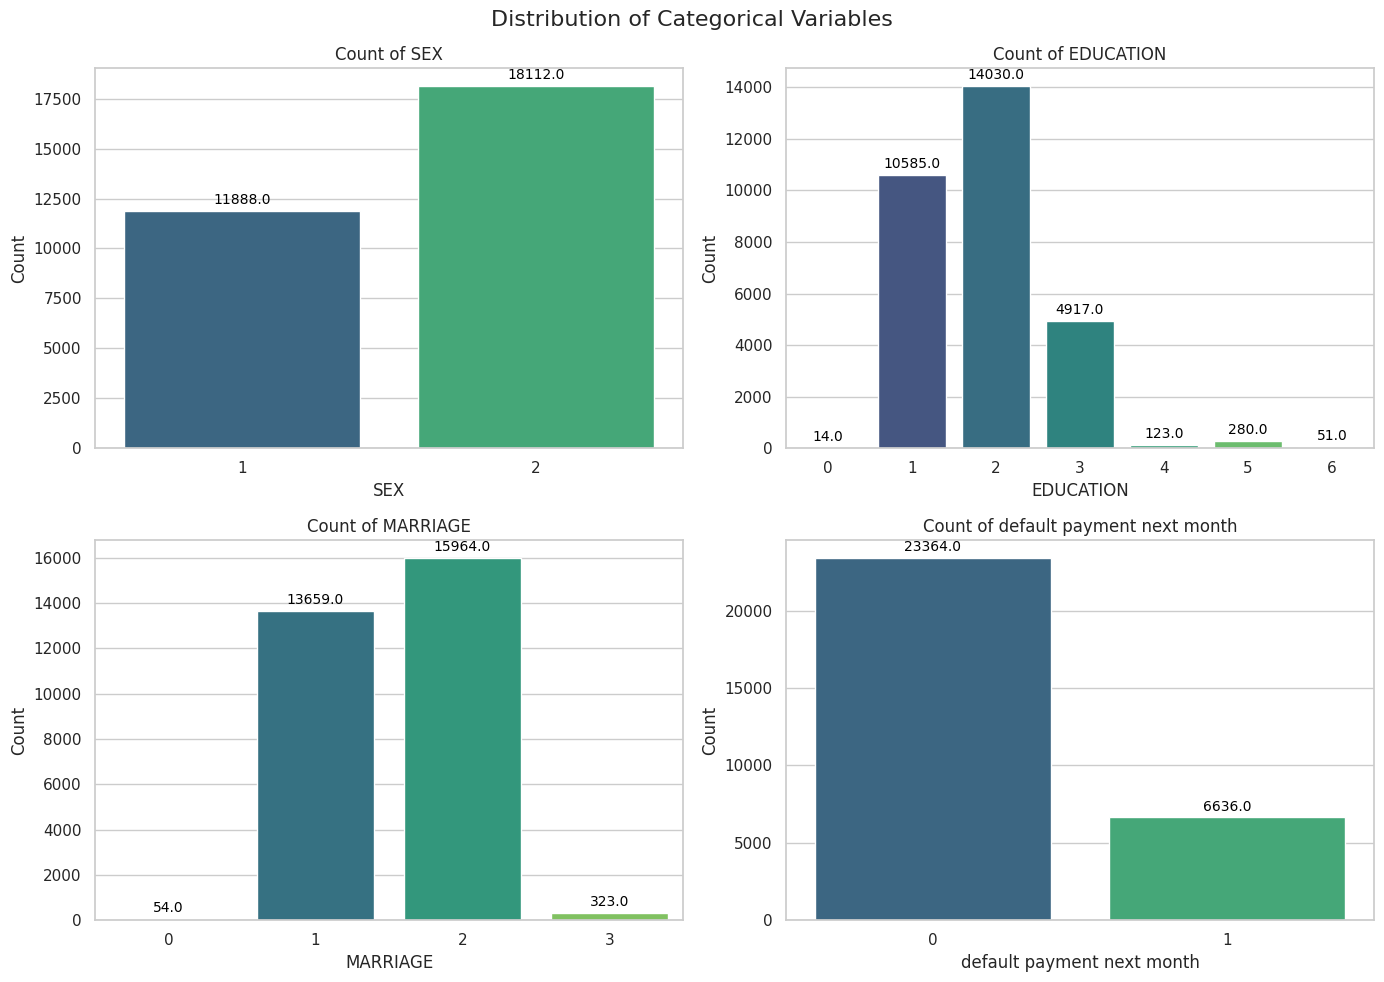

In [9]:
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE', 'default payment next month']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Categorical Variables', fontsize=16)

for ax, col in zip(axes.flatten(), categorical_cols):
    sns.countplot(data=Raw_data, x=col, ax=ax, palette='viridis')
    ax.set_title(f'Count of {col}')
    ax.set_ylabel('Count')
    
    # Add value counts on top of bars
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                    textcoords='offset points')

plt.tight_layout()
plt.show()

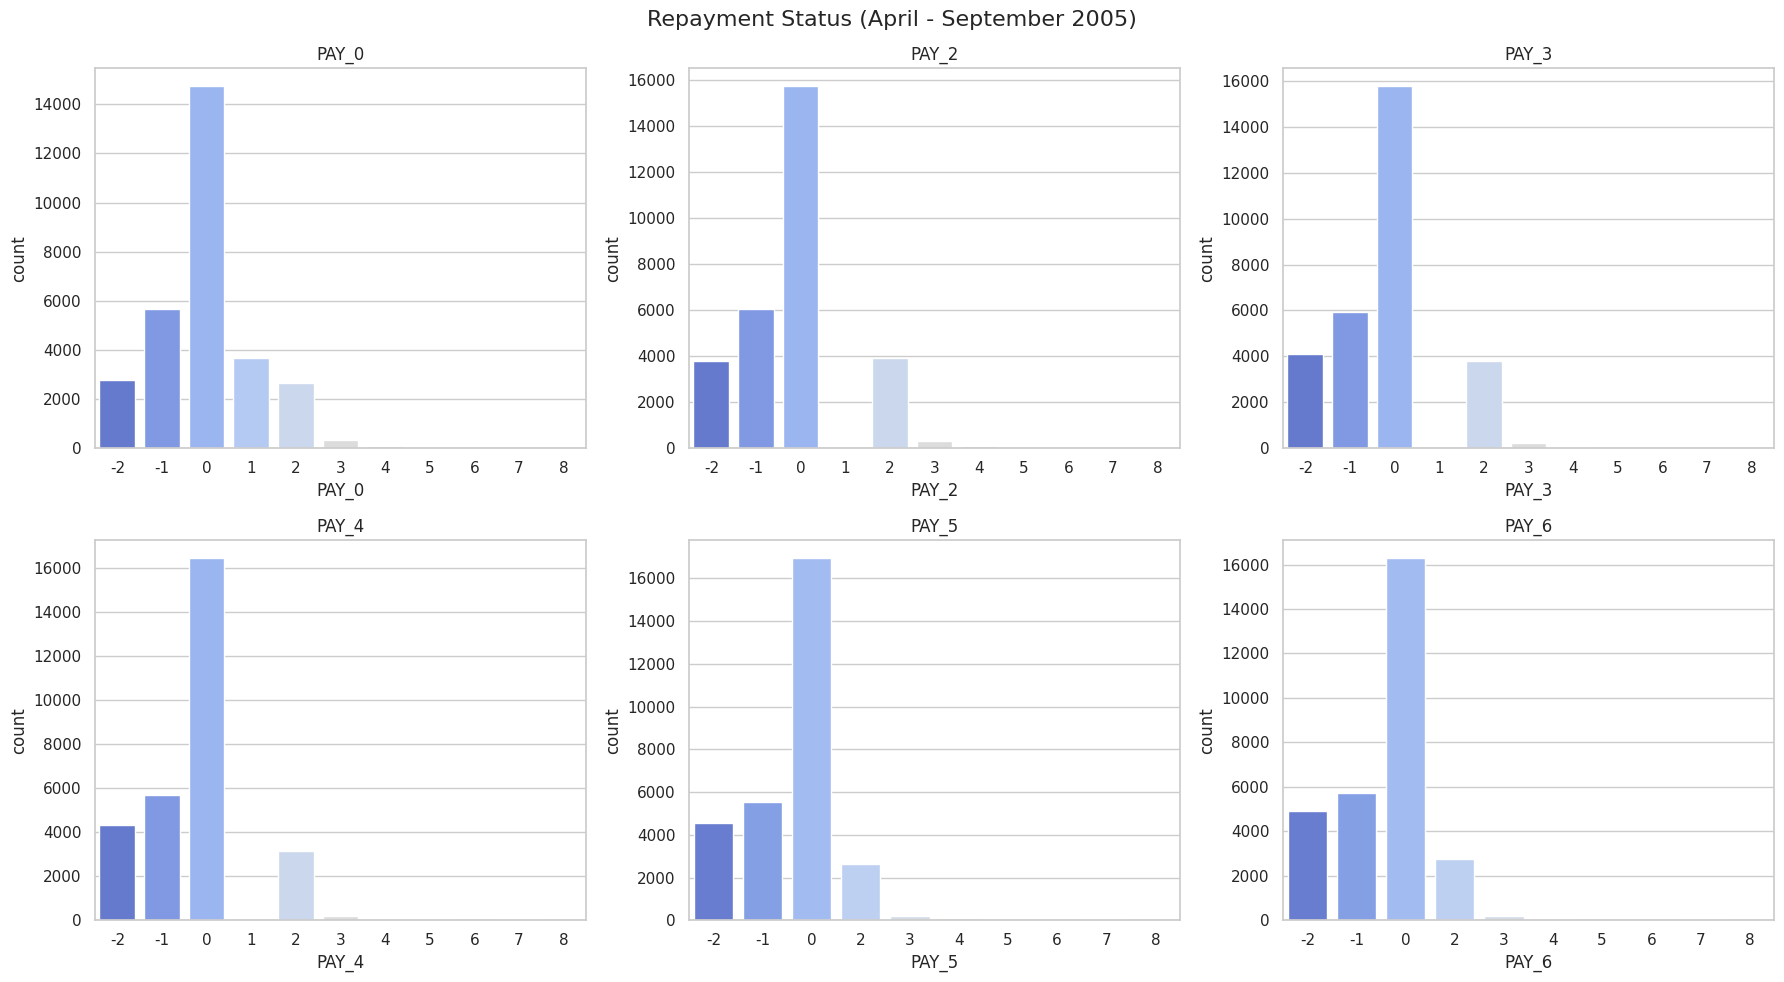

In [10]:
# Repayment status distributions (PAY_0 to PAY_6)
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Repayment Status (April - September 2005)', fontsize=16)

for ax, col in zip(axes.flatten(), pay_cols):
    sns.countplot(data=Raw_data, x=col, ax=ax, palette='coolwarm')
    ax.set_title(col)

plt.tight_layout()
plt.show()

### **Exploratory Data Analysis - Continuous Variables & Outlier Identification**
Now, we look at the distributions of continuous variables like `LIMIT_BAL`, `AGE`, and the `BILL_AMT` / `PAY_AMT` columns. 

**Expected Observations & Outlier Identification:**
* **LIMIT_BAL:** Often heavily right-skewed. There are usually extreme high-credit-limit outliers.
* **AGE:** Mostly concentrated between 20 and 40 years old.
* **BILL_AMT & PAY_AMT:** These financial columns typically contain heavy outliers (massive singular payments or massive bills) that can skew regression models. We will use Boxplots to visualize these outliers visually and later use the Interquartile Range (IQR) method to cap them.

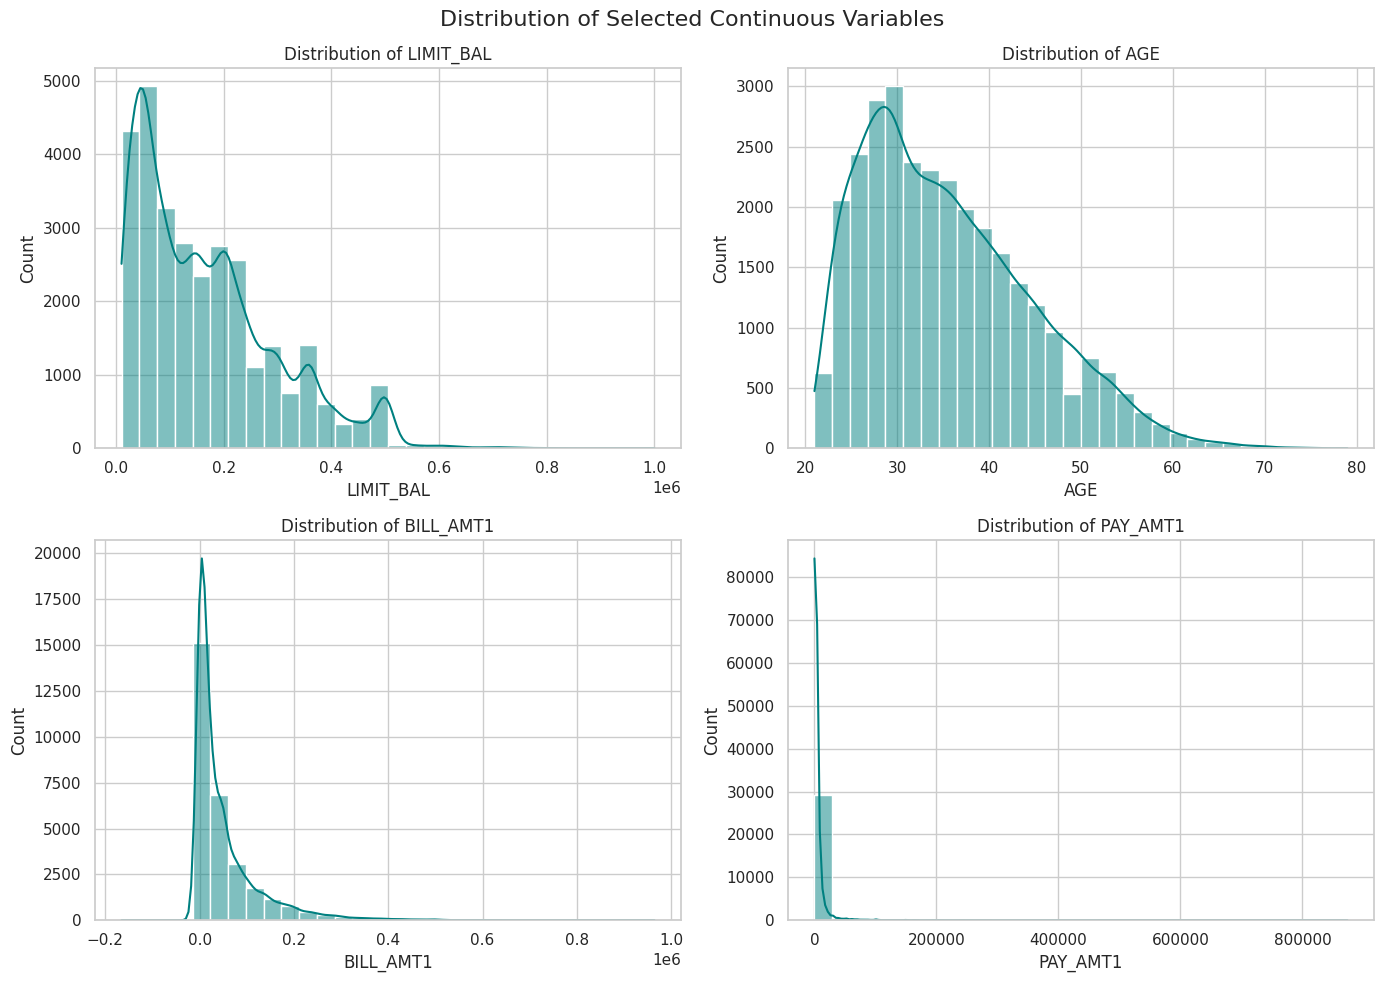

In [11]:
continuous_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']

# Histograms for distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Selected Continuous Variables', fontsize=16)

for ax, col in zip(axes.flatten(), continuous_cols):
    sns.histplot(Raw_data[col], bins=30, kde=True, ax=ax, color='teal')
    ax.set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

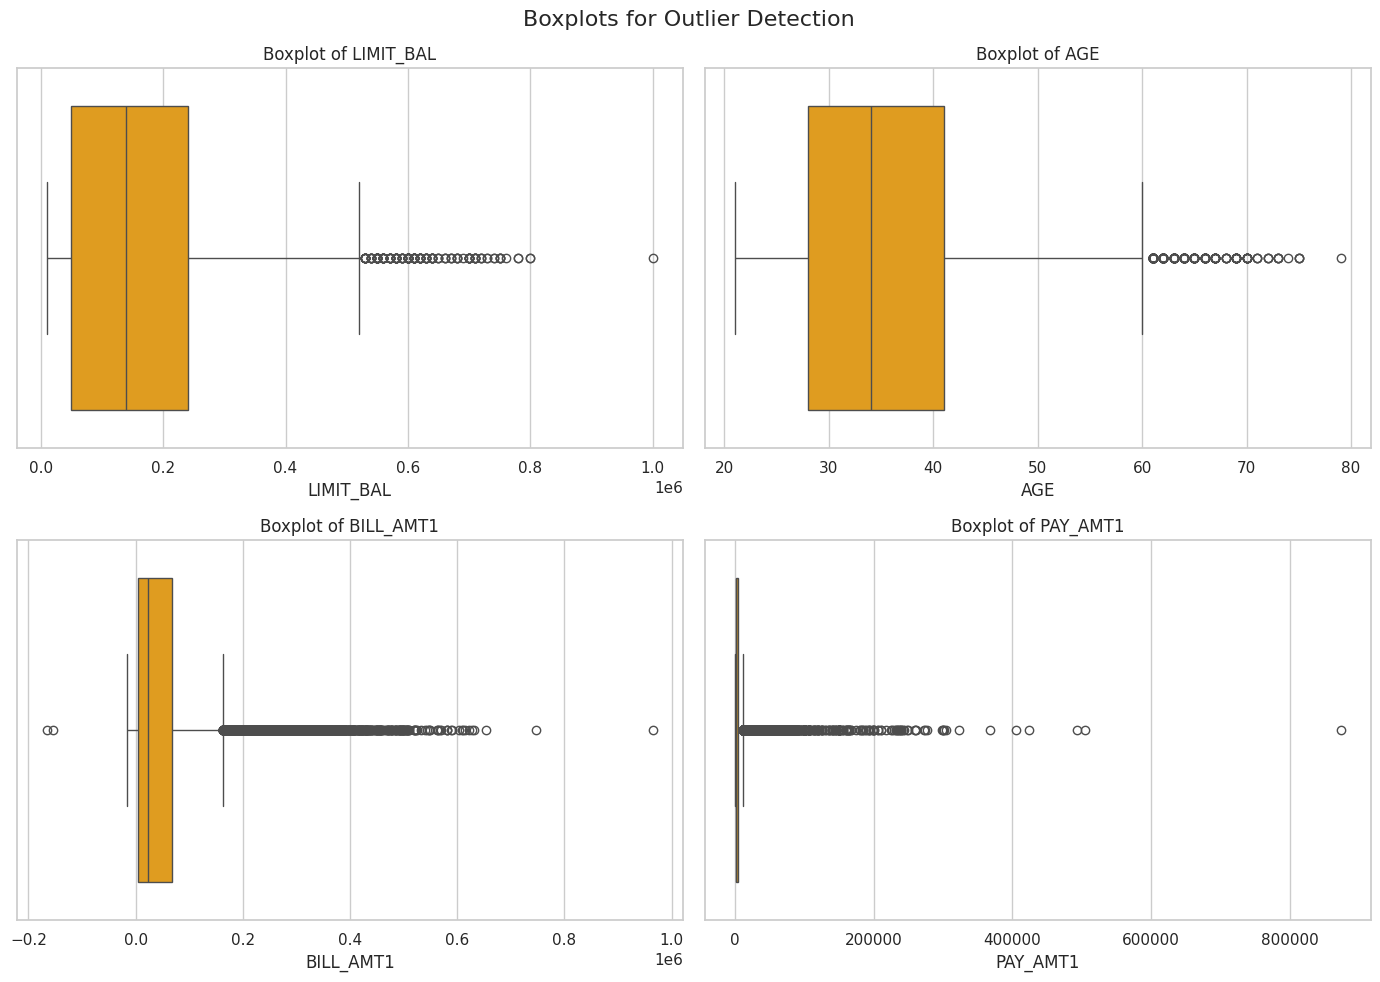

In [12]:
# Boxplots for Outlier Identification
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Boxplots for Outlier Detection', fontsize=16)

for ax, col in zip(axes.flatten(), continuous_cols):
    sns.boxplot(x=Raw_data[col], ax=ax, color='orange')
    ax.set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

### **Data Preparation & Outlier Treatment**
To prepare the data for the Gradient Boosting Regressor:
1.  **Outlier Capping:** We will cap extreme values in the financial columns (`BILL_AMT` and `PAY_AMT`) using the 1st and 99th percentiles to avoid removing too much data while taming extreme spikes.
2.  **Scaling:** Gradient Boosting algorithms are relatively robust to unscaled data, but scaling continuous features ensures stable learning.
3.  **Feature Split:** We separate our independent variables ($X$) from our dependent variable ($y$).

In [13]:
# Create a copy for preparation
data_prep = Raw_data.copy()

# Identify financial columns
financial_cols = [col for col in Raw_data.columns if 'AMT' in col or col == 'LIMIT_BAL']

# Cap outliers at the 1st and 99th percentiles
for col in financial_cols:
    lower_limit = data_prep[col].quantile(0.01)
    upper_limit = data_prep[col].quantile(0.99)
    data_prep[col] = np.clip(data_prep[col], lower_limit, upper_limit)

# Separate X and y
X = data_prep.drop(columns=['default payment next month'])
y = data_prep['default payment next month']

# Split the data (70% training, 30% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (21000, 24)
Testing data shape: (9000, 24)


### **Model Training (Gradient Boosting Regression)**
In alignment with the study's perspective on risk management, predicting the *continuous probability* of a default provides more granular risk assessment than binary classification. 

We apply the **Gradient Boosting Regressor** to predict $y$. Since $y \in \{0, 1\}$, the regression output will naturally constrain itself roughly between 0 and 1, representing the estimated probability of default.

In [14]:
# Initialize and train the Gradient Boosting Regressor
# We use standard hyperparameters, but these can be tuned later via GridSearchCV
gbr = GradientBoostingRegressor(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3, 
    random_state=42
)

print("Training the Gradient Boosting Regressor...")
gbr.fit(X_train_scaled, y_train)

Training the Gradient Boosting Regressor...


GradientBoostingRegressor(random_state=42)

In [15]:
# Predict probabilities on the test set
y_pred = gbr.predict(X_test_scaled)

# Ensure predictions are strictly bounded between 0 and 1 (as they represent probability)
y_pred_prob = np.clip(y_pred, 0, 1)

# Evaluation Metrics
mse = mean_squared_error(y_test, y_pred_prob)
mae = mean_absolute_error(y_test, y_pred_prob)
r2 = r2_score(y_test, y_pred_prob)

print("\nModel Evaluation (Predicting Probability of Default):")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Coefficient of Determination (R-squared): {r2:.4f}")


Model Evaluation (Predicting Probability of Default):
Mean Squared Error (MSE): 0.1343
Mean Absolute Error (MAE): 0.2691
Coefficient of Determination (R-squared): 0.2118


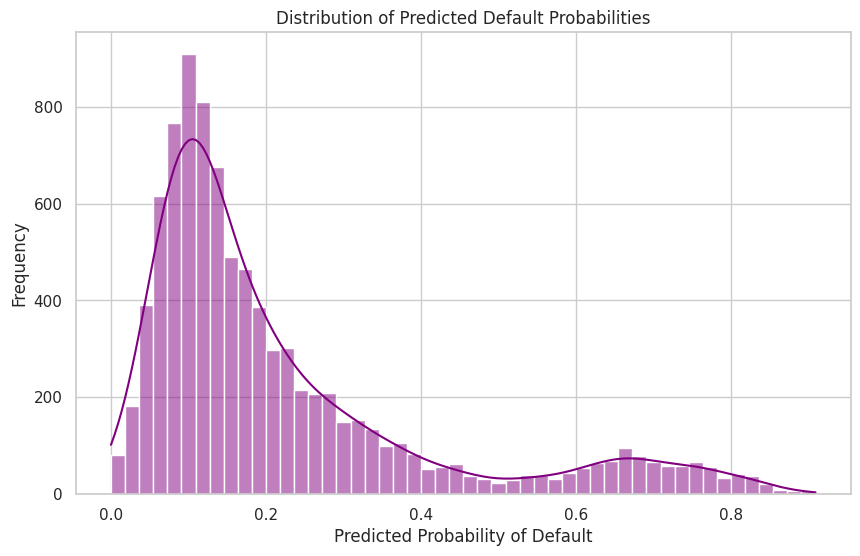

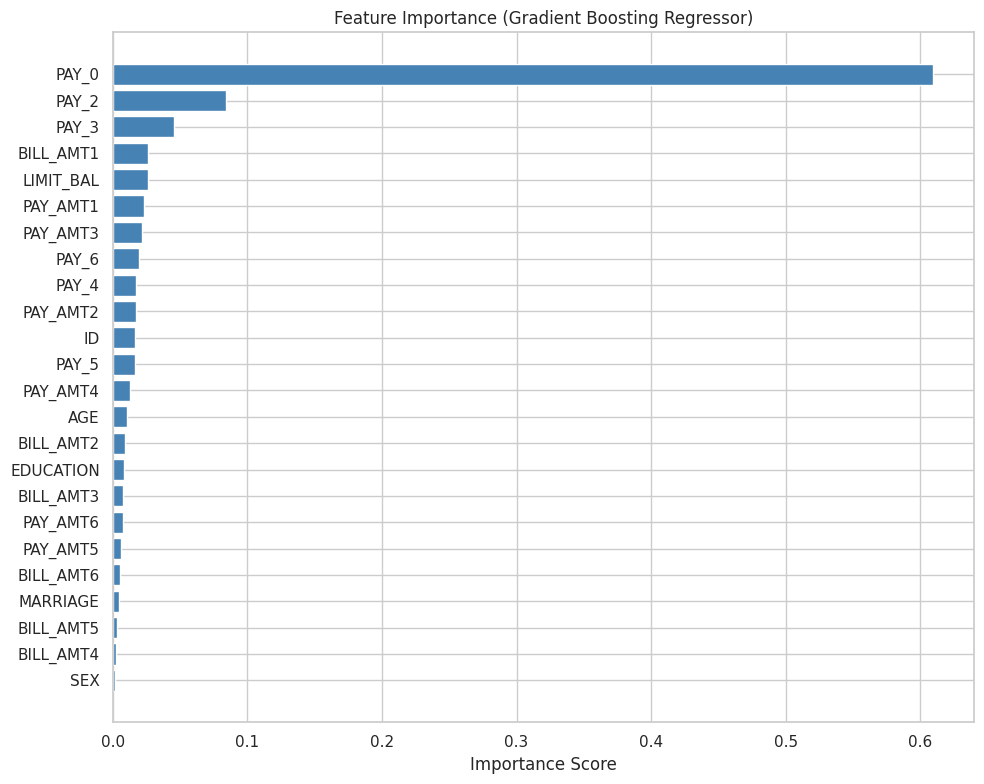

In [16]:
# Visualize Predicted Probabilities
plt.figure(figsize=(10, 6))
sns.histplot(y_pred_prob, bins=50, kde=True, color='purple')
plt.title('Distribution of Predicted Default Probabilities')
plt.xlabel('Predicted Probability of Default')
plt.ylabel('Frequency')
plt.show()

# Feature Importance
feature_importance = gbr.feature_importances_
sorted_idx = np.argsort(feature_importance)

plt.figure(figsize=(10, 8))
plt.barh(np.array(X.columns)[sorted_idx], feature_importance[sorted_idx], color='steelblue')
plt.title("Feature Importance (Gradient Boosting Regressor)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()